In [ ]:
from typing import Callable, ClassVar, Literal

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from clawpack import pyclaw, riemann
from context_flux_no.simulations.pdesolve import pdesolve_pyclaw
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_enable_x64", True)

In [2]:
class TruncatedFourier1D(eqx.Module):
    an: Float[Array, " K"]
    bn: Float[Array, " K"]
    a0: Float[Array, ""] = eqx.field(default_factory=lambda: jnp.array(0.0))
    L: float = eqx.field(static=True, default=1.0)

    def __call__(self, x: Float[Array, " *shape"]):
        kx: Float[Array, "*shape K"] = jnp.expand_dims(x, axis=-1) * self.wavenumbers
        cos_kx, sin_kx = jnp.cos(kx), jnp.sin(kx)
        return self.a0 + jnp.mean(
            self.an * cos_kx + self.bn * sin_kx, axis=-1
        ) / jnp.sqrt(2)

    @property
    def num_modes(self) -> int:
        return len(self.an)

    @property
    def wavenumbers(self) -> Float[Array, " K"]:
        return jnp.arange(1, self.num_modes + 1) * 2 * jnp.pi / self.L

    @classmethod
    def with_uniform_rand_coeffs(
        cls,
        num_modes: int,
        L: float = 1.0,
        coeff_range: tuple[float, float] = (1, 1),
        offset_range: tuple[float, float] | None = None,
        *,
        key: PRNGKeyArray = jax.random.PRNGKey(0),
    ):
        key_coeff, key_offset = jax.random.split(key, 2)
        an_bn = jax.random.uniform(
            key_coeff,
            shape=(2, num_modes),
            minval=coeff_range[0],
            maxval=coeff_range[1],
        )
        if offset_range is None:
            a0 = jnp.array(0.0)
        else:
            a0 = jax.random.uniform(
                key_offset, minval=offset_range[0], maxval=offset_range[1]
            )
        return cls(*an_bn, a0, L)

INFO:2025-08-10 00:02:00,356:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2025-08-10 00:02:00,356 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


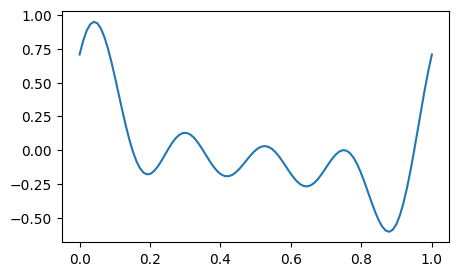

In [3]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [ ]:
class Burgers1D(eqx.Module):
    n_dim: ClassVar[int] = 1
    n_eqns: ClassVar[int] = 1
    nu: float = eqx.field(static=True, default=0.0)
    entropy_fix: bool = eqx.field(static=True, default=True)

    def solve_pyclaw(
        self,
        ic_factory: Callable[[Float[np.ndarray, " Nx"]], Float[np.ndarray, " Nx"]],
        x_span: tuple[float, float],
        Nx: int,
        t_span: tuple[float, float],
        Nt: int,
        bc: Literal["periodic"],
    ) -> tuple[
        Float[np.ndarray, "time dim x_grid"],
        Float[np.ndarray, " time"],
        Float[np.ndarray, " x_grid"],
    ]:
        solver = pyclaw.ClawSolver1D(riemann.burgers_1D)
        solver.limiters = pyclaw.limiters.tvd.vanleer

        problem_data = {"efix": self.entropy_fix}
        return pdesolve_pyclaw(
            solver, problem_data, ic_factory, x_span, Nx, t_span, Nt, bc
        )


In [20]:
burgers = Burgers1D()
u0_func = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
u, t, x = burgers.solve_pyclaw(u0_func, (0.0, 1.0), 1024, (0.0, 6.0), 1000, "periodic")

2025-08-10 00:14:18,628 INFO CLAW: Solution 0 computed for time t=0.000000
2025-08-10 00:14:18,631 INFO CLAW: Solution 1 computed for time t=0.006000
2025-08-10 00:14:18,632 INFO CLAW: Solution 2 computed for time t=0.012000
2025-08-10 00:14:18,634 INFO CLAW: Solution 3 computed for time t=0.018000
2025-08-10 00:14:18,635 INFO CLAW: Solution 4 computed for time t=0.024000
2025-08-10 00:14:18,637 INFO CLAW: Solution 5 computed for time t=0.030000
2025-08-10 00:14:18,638 INFO CLAW: Solution 6 computed for time t=0.036000
2025-08-10 00:14:18,640 INFO CLAW: Solution 7 computed for time t=0.042000
2025-08-10 00:14:18,642 INFO CLAW: Solution 8 computed for time t=0.048000
2025-08-10 00:14:18,643 INFO CLAW: Solution 9 computed for time t=0.054000
2025-08-10 00:14:18,645 INFO CLAW: Solution 10 computed for time t=0.060000
2025-08-10 00:14:18,646 INFO CLAW: Solution 11 computed for time t=0.066000
2025-08-10 00:14:18,648 INFO CLAW: Solution 12 computed for time t=0.072000
2025-08-10 00:14:18,64

In [ ]:
import logging


logger = logging.getLogger("pyclaw")
logger.__dict__

{'filters': [],
 'name': 'pyclaw',
 'level': 20,
 'parent': <RootLogger root (INFO)>,
 'propagate': 1,
 'handlers': [<FileHandler /home/jhko725/projects/CONTEXT_FLUX_NO/notebooks/data_generation/pyclaw.log (NOTSET)>,
  <StreamHandler stdout (INFO)>],
 'disabled': 0,
 '_cache': {},
 'manager': <logging.Manager at 0x154451893020>}

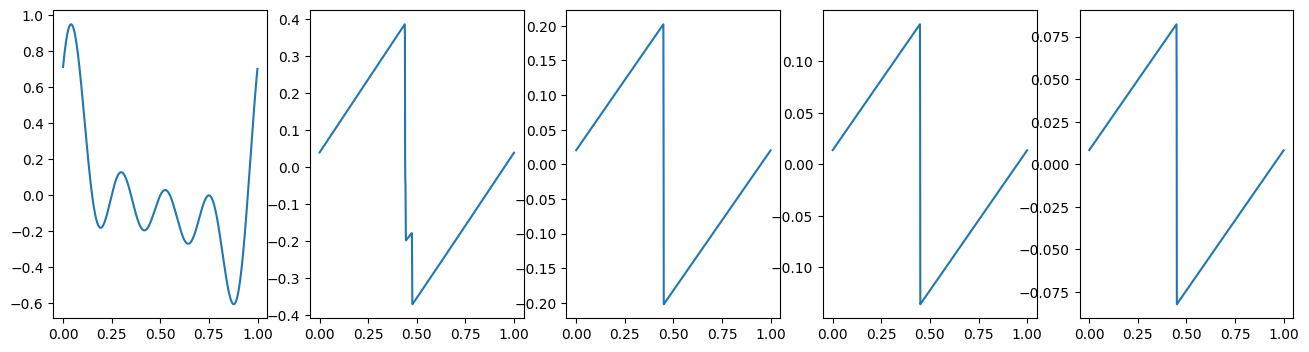

In [21]:
t_vals = (0, 200, 400, 600, 1000)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
for j, t_i in enumerate(t_vals):
    axes[j].plot(x, u[t_i, 0])

In [22]:
import xarray as xr


data_array = xr.DataArray(
    np.expand_dims(u, axis=0),
    coords={
        "t": t,
        "x": x,
        "dim": [
            "u",
        ],
        "nu": ("sample", [0.0]),
    },
    dims=["sample", "t", "dim", "x"],
)

In [23]:
data_array

<xarray.DataArray (sample: 1, t: 1001, dim: 1, x: 1024)> Size: 8MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.66683561, 0.67753383, 0.6880781 , ..., 0.63385509,
          0.64499243, 0.65598721]],

        [[0.62443636, 0.63496599, 0.64538165, ..., 0.59219562,
          0.603048  , 0.61379597]],

        ...,

        [[0.00833087, 0.00849227, 0.00865368, ..., 0.00784664,
          0.00800805, 0.00816946]],

        [[0.00832261, 0.00848386, 0.0086451 , ..., 0.00783887,
          0.00800012, 0.00816137]],

        [[0.00831438, 0.00847546, 0.00863655, ..., 0.00783111,
          0.0079922 , 0.00815329]]]], shape=(1, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.006 0.012 0.018 ... 5.982 5.988 5.994 6.0
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 8B 0.0
Dimensions without coordinates: sample

In [31]:
xr.concat((data_array, data_array), "sample")

<xarray.DataArray (sample: 2, t: 1001, dim: 1, x: 1024)> Size: 16MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.70781315, 0.7184767 , 0.72894027, ..., 0.67466297,
          0.68590216, 0.69695361]],

        [[0.70314593, 0.71382476, 0.72430918, ..., 0.66998341,
          0.68122115, 0.69227671]],

        ...,

        [[0.07582843, 0.07729656, 0.07876473, ..., 0.07142431,
          0.07289231, 0.07436035]],

        [[0.0757601 , 0.0772269 , 0.07869374, ..., 0.07135995,
          0.07282662, 0.07429334]],

        [[0.07569188, 0.07715736, 0.07862289, ..., 0.0712957 ,
          0.07276105, 0.07422645]]],


       [[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.70781315, 0.7184767 , 0.72894027, ..., 0.67466297,
          0.68590216, 0.69695361]],

        [[0.70314593, 0.71382476, 0.72430918, ..., 0.66998341,
          0.68122115, 0.69227671]],

        ...,

        [[0.07582843, 0.07729656, 0.07876473, ..., 0.07142431,
          0.07289231, 0.07436035]],

        [[0.0757601 , 0.0772269 , 0.07869374, ..., 0.07135995,
          0.07282662, 0.07429334]],

        [[0.07569188, 0.07715736, 0.07862289, ..., 0.0712957 ,
          0.07276105, 0.07422645]]]], shape=(2, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.0006 0.0012 0.0018 ... 0.5988 0.5994 0.6
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 16B 0.0 0.0
Dimensions without coordinates: sample

In [37]:
data_array.coords["nu"].dims

('sample',)

In [ ]:
from context_flux_no.models.fno import FNO1D


fno = FNO1D(
    data_dim=1, lift_dim=64, depth=4, frequency_modes=8, key=jax.random.PRNGKey(0)
)


In [13]:
out = fno(sol[0])

2025-07-29 01:36:37.117089: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-07-29 01:36:40.975288: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.858323399s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

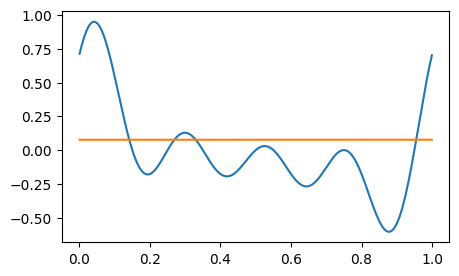

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[0][0])
ax.plot(xc, out[0])

In [15]:
sol[1:501].shape

(500, 1, 1024)

In [16]:
import optax


@eqx.filter_value_and_grad
def loss_fn(model, u0, u1):
    u1_pred = eqx.filter_vmap(model)(u0)
    return jnp.mean((u1_pred - u1) ** 2)


optim = optax.adabelief(learning_rate=1e-3)
opt_state = optim.init(eqx.filter(fno, eqx.is_array))


@eqx.filter_jit
def make_step(model, u0, u1, opt_state):
    loss, grads = loss_fn(model, u0, u1)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [22]:
max_epochs = 500
loss_history = []
for i in range(max_epochs):
    fno, opt_state, loss = make_step(fno, sol[0:300], sol[1:301], opt_state)
    loss_history.append(loss)
    print(f"Epoch = {i}: Loss = {loss.item()}")

Epoch = 0: Loss = 0.00020421074658257243
Epoch = 1: Loss = 0.00014109168473465345
Epoch = 2: Loss = 0.0001617548698729333
Epoch = 3: Loss = 0.0001677714428678142
Epoch = 4: Loss = 0.00012144901944100197
Epoch = 5: Loss = 0.00016602083143685232
Epoch = 6: Loss = 0.0001357075982198397
Epoch = 7: Loss = 0.00013018305315784629
Epoch = 8: Loss = 0.00014964680985533993
Epoch = 9: Loss = 0.00012164262753276757
Epoch = 10: Loss = 0.00013917721858387248
Epoch = 11: Loss = 0.00013439717139500522
Epoch = 12: Loss = 0.00011805309309739107
Epoch = 13: Loss = 0.0001374891835581763
Epoch = 14: Loss = 0.0001241620070103194
Epoch = 15: Loss = 0.0001221958545635538
Epoch = 16: Loss = 0.00013080572037865317
Epoch = 17: Loss = 0.00011635836484363279
Epoch = 18: Loss = 0.00012365914155873433
Epoch = 19: Loss = 0.00012510949754455044
Epoch = 20: Loss = 0.0001159500258631523
Epoch = 21: Loss = 0.0001224002390939585
Epoch = 22: Loss = 0.00011942344283503516
Epoch = 23: Loss = 0.00011550717089296924
Epoch = 24

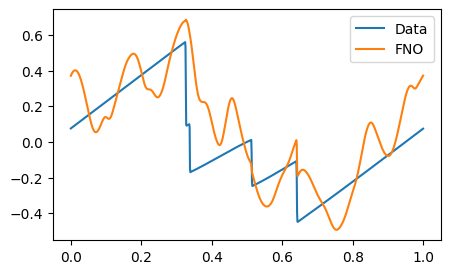

In [24]:
time_idx = 999
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[time_idx + 1][0], label="Data")
ax.plot(xc, fno(sol[time_idx])[0], label="FNO")
ax.legend()

In [20]:
sol[time_idx][0:1].shape

(1, 1024)

In [ ]:
from context_flux_no.nn.fourier import (
    SpectralConv1D,
    SpectralConv1D as SpectralConv1D_new,
)


time_idx = 1000
conv1 = SpectralConv1D(1, 32, 15, key=jax.random.key(0))
conv2 = SpectralConv1D_new(1, 32, 15, key=jax.random.key(0))

jnp.max(conv1(sol[time_idx][0:1]))

Array(0.0183449, dtype=float64)

In [21]:
jnp.max(conv2(sol[time_idx][0:1]))

out_fft_shape_new=(Array(32, dtype=int64, weak_type=True), Array(513, dtype=int64, weak_type=True))


Array(0.0183449, dtype=float64)

In [20]:
jnp.all(conv1(sol[time_idx][0:1]) == conv2(sol[time_idx][0:1]))

out_fft_shape_new=(Array(32, dtype=int64, weak_type=True), Array(513, dtype=int64, weak_type=True))


Array(True, dtype=bool)

In [21]:
jnp.all(
    jax.grad(lambda x: jnp.mean(conv1(x)))(sol[time_idx][0:1])
    == jax.grad(lambda x: jnp.mean(conv2(x)))(sol[time_idx][0:1])
)

out_fft_shape_new=(Array(32, dtype=int64, weak_type=True), Array(513, dtype=int64, weak_type=True))


Array(True, dtype=bool)